# SPARC4 · Trânsitos planetários — AU Mic b

Ajuste do trânsito parcial de AU Mic b na noite 2026-07-19 (época 344),
nos quatro canais do SPARC4, com modelo de `batman`.

Ordem das células:

1. configuração (noite, efeméride, parâmetros do planeta e do escurecimento de bordo)
2. leitura dos produtos, fotometria diferencial, BJD_UTC -> BJD_TDB e massa de ar
3. previsão do trânsito e cobertura da observação
4. escolha da abertura e das estrelas de comparação (critério só fora do trânsito)
5. máscara de flares, binning e ruído real por banda
6. ajuste: varredura em Tc + solução linear da profundidade e da linha de base
7. robustez do resultado (varia linha de base e janela)
8. figuras
9. MCMC (emcee)
10. gravação em `resultados_transitos/`


In [1]:
print("end=")

end=


In [2]:
# ═══ SPARC4 · TRÂNSITOS PLANETÁRIOS · AU Mic b ═══════════════════════════════
# Configuração da noite, da efeméride e dos parâmetros do trânsito.
import os

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
NIGHT  = "20260719"        # noite com o trânsito parcial de AU Mic b
OUTDIR = os.path.join(BASE, "resultados_transitos")

NIGHT_DIR   = os.path.join(BASE, "data", NIGHT)
NIGHT_LABEL = f"{NIGHT[:4]}-{NIGHT[4:6]}-{NIGHT[6:]}"
os.makedirs(OUTDIR, exist_ok=True)

# ── produtos ─────────────────────────────────────────────────────────────────
CHANNELS  = [1, 2, 3, 4]
BANDS     = {1: "g", 2: "r", 3: "i", 4: "z"}
BEAM      = "S+N"          # soma dos feixes: cancela a modulação da lâmina
APER_WANT = 12             # raio de abertura desejado (px)
NCOMPS    = 3              # nº de estrelas de comparação
OVERRIDE  = {}             # {canal: (alvo, [comps])} se a escolha automática falhar

# ── escala de tempo ──────────────────────────────────────────────────────────
# O header do SPARC4 traz TIMEKEY='BJD' com TIMESCL='utc'  ->  BJD_UTC.
# A efeméride (TESS/BTJD) está em BJD_TDB. TDB-UTC = 69.184 s em 2026, que é
# ~1.2 min: da ordem da incerteza da efeméride, então a conversão importa.
TIME_IN_SCALE = "utc"      # "utc" converte para TDB; "tdb" usa como está

# ── efeméride de AU Mic b (MCMC dos setores 1, 27 e 95 — mcmc_auMic_b_ephx1) ──
BTJD0     = 2457000.0
T0_BTJD   = 1330.3864186   # ± 0.00072 d
T0_ERR    = 0.00072
PER       = 8.4631566      # ± 0.0000050 d
PER_ERR   = 0.0000050
T0_TDB    = T0_BTJD + BTJD0

# ── parâmetros do trânsito (Plavchan+2020 / Martioli+2021) ───────────────────
RP_RS   = 0.0526           # Rp/R*  -> profundidade ~ 2.8 ppt
A_RS    = 19.1             # a/R*
INC     = 89.5             # graus
ECC, W  = 0.0, 90.0

# limb darkening quadrático por banda, AU Mic (Teff 3700 K, logg 4.5, [Fe/H] 0).
# Valores aproximados de tabelas de Claret para o sistema SDSS — troque por
# ldtk/exotic-ld se precisar de precisão nos coeficientes.
LDC = {"g": [0.62, 0.28], "r": [0.55, 0.32],
       "i": [0.40, 0.33], "z": [0.30, 0.32]}

# ── estrela ──────────────────────────────────────────────────────────────────
R_STAR, M_STAR, T_EFF = 0.75, 0.50, 3700.0     # R_sol, M_sol, K

print(f"noite      : {NIGHT_LABEL}   ({NIGHT_DIR})")
print(f"efeméride  : T0 = {T0_TDB:.6f} BJD_TDB ± {T0_ERR*24*60:.2f} min   "
      f"P = {PER:.7f} ± {PER_ERR*24*3600:.2f} s")
print(f"profundidade esperada = {RP_RS**2*1e3:.2f} ppt")
print(f"saídas em  : {OUTDIR}")



noite      : 2026-07-19   (C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\data\20260719)
efeméride  : T0 = 2458330.386419 BJD_TDB ± 1.04 min   P = 8.4631566 ± 0.43 s
profundidade esperada = 2.77 ppt
saídas em  : C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos


In [3]:
# ═══ 1 · leitura dos produtos, fotometria diferencial e massa de ar ══════════
import glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.stats import sigma_clip
import astropy.units as u

DATADIR = NIGHT_DIR
cols_b  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

def _find(pat):
    f = sorted(glob.glob(os.path.join(DATADIR, "**", pat), recursive=True))
    if not f:
        raise FileNotFoundError(f"{pat} em {DATADIR}")
    return f[0]

def _aps(fname):
    with fits.open(fname) as h:
        out = {}
        for e in h:
            m = re.search(r"AP0*(\d+)$", e.name or "")
            if m:
                out.setdefault(int(m.group(1)), []).append(e.name)
    return out

_COLS = ["MAG", "EMAG", "FWHM", "SKYMAG", "X", "Y", "WPPOS"]

def load_cat(lcfile, cat):
    """-> t(nt,), idx(ns,), {coluna: (ns,nt)}, header primário."""
    with fits.open(lcfile) as h:
        d, hdr, hdr0 = h[cat].data, h[cat].header, h[0].header
        nomes = d.columns.names
        t0    = float(hdr.get("TIME0", 0.0))
        src   = np.asarray(d["SRCINDEX"])
        time  = np.asarray(d["TIME"], float)
        flag  = np.asarray(d["FLAG"]) if "FLAG" in nomes else None
        raw   = {c: np.asarray(d[c], float) for c in _COLS if c in nomes}

    if raw["MAG"].ndim == 2:
        idx = (src[:, 0] if src.ndim == 2 else src).astype(int)
        t   = (time[0] if time.ndim == 2 else time).astype(float)
        out = {c: v.copy() for c, v in raw.items()}
        if flag is not None and np.shape(flag) == raw["MAG"].shape:
            out["MAG"] = np.where(np.asarray(flag) != 0, np.nan, out["MAG"])
    else:
        src = src.astype(int)
        idx, t = np.unique(src), np.unique(time)
        col, row = np.searchsorted(t, time), np.searchsorted(idx, src)
        out = {}
        for c, v in raw.items():
            A = np.full((idx.size, t.size), np.nan);  A[row, col] = v
            out[c] = A
        if flag is not None:
            bad = np.full((idx.size, t.size), False)
            bad[row, col] = np.asarray(flag) != 0
            out["MAG"] = np.where(bad, np.nan, out["MAG"])
    if np.nanmax(t) < 1e5:
        t = t + t0
    return t, idx, out, hdr0

def para_tdb(t_bjd):
    """BJD_UTC -> BJD_TDB (soma TDB-UTC ~ 69.2 s em 2026)."""
    if TIME_IN_SCALE.lower() == "tdb":
        return np.asarray(t_bjd, float)
    return Time(np.asarray(t_bjd, float), format="jd", scale="utc").tdb.jd

def massa_ar(t_bjd, hdr0):
    loc = EarthLocation(lat=float(hdr0["OBSLAT"]) * u.deg,
                        lon=float(hdr0["OBSLONG"]) * u.deg,
                        height=float(hdr0["OBSALT"]) * u.m)
    alvo = SkyCoord(float(hdr0["RA"]) * u.deg, float(hdr0["DEC"]) * u.deg, frame="icrs")
    tt   = Time(np.asarray(t_bjd, float), format="jd", scale="utc")
    return alvo.transform_to(AltAz(obstime=tt, location=loc)).secz.value

dados, hdr_ref = {}, None
for ch in CHANNELS:
    try:
        lf = _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
    except FileNotFoundError:
        print(f"c{ch}: sem produto {BEAM}");  continue
    aps  = _aps(lf)
    aper = min(aps, key=lambda a: abs(a - APER_WANT))
    cat  = aps[aper][0]

    t_utc, idx, A, hdr0 = load_cat(lf, cat)
    hdr_ref = hdr_ref or hdr0
    M, E = A["MAG"], A["EMAG"]

    if ch in OVERRIDE:
        tgt, cps = OVERRIDE[ch]
    else:
        ordem = idx[np.argsort(np.nanmedian(M, axis=1))]
        tgt, cps = int(ordem[0]), [int(i) for i in ordem[1:1 + NCOMPS]]
    it = int(np.where(idx == tgt)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in cps]

    k  = 0.4 * np.log(10)
    with np.errstate(invalid="ignore", divide="ignore"):
        ft, et = 10 ** (-0.4 * M[it]), k * 10 ** (-0.4 * M[it]) * E[it]
        fc = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        ec = np.sqrt(np.nansum((k * 10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
        r  = ft / fc
        er = r * np.hypot(et / ft, ec / fc)
    ok = np.isfinite(r) & np.isfinite(er) & (er > 0)

    dados[ch] = dict(band=BANDS[ch], file=os.path.basename(lf), aper=aper,
                     alvo=tgt, comps=cps,
                     t=para_tdb(t_utc)[ok], t_utc=t_utc[ok],
                     f=r[ok] / np.nanmedian(r[ok]), ef=er[ok] / np.nanmedian(r[ok]),
                     X=massa_ar(t_utc, hdr0)[ok],
                     fwhm=A["FWHM"][it][ok] if "FWHM" in A else np.full(ok.sum(), np.nan))
    d = dados[ch]
    print(f"c{ch} ({BANDS[ch]}'): {d['t'].size:6d} pontos | AP{aper:03d} | "
          f"alvo={tgt} comps={cps} | cad={np.median(np.diff(d['t']))*86400:.2f} s | "
          f"rms={np.nanstd(d['f'])*1e3:.2f} ppt")

TSTART = min(d["t"].min() for d in dados.values())
TSTOP  = max(d["t"].max() for d in dados.values())
T_REF  = np.floor(TSTART)
print(f"\njanela observada (BJD_TDB): {TSTART:.6f} .. {TSTOP:.6f}  "
      f"= {(TSTOP-TSTART)*24:.2f} h")
print(f"                     (UTC): {Time(TSTART, format='jd').isot}  ..  "
      f"{Time(TSTOP, format='jd').isot}")
if TIME_IN_SCALE.lower() == "utc":
    _d0 = dados[chs_ok[0]] if (chs_ok := sorted(dados)) else None
    print(f"correção UTC->TDB aplicada: "
          f"{(_d0['t'][0] - _d0['t_utc'][0]) * 86400:.3f} s por ponto")



c1 (g'):   7039 pontos | AP012 | alvo=0 comps=[1, 3, 2] | cad=2.42 s | rms=7.62 ppt
c2 (r'):  14077 pontos | AP012 | alvo=0 comps=[1, 2, 3] | cad=1.22 s | rms=13.89 ppt
c3 (i'):  14077 pontos | AP012 | alvo=0 comps=[1, 2, 3] | cad=1.22 s | rms=22.06 ppt
c4 (z'):  14075 pontos | AP012 | alvo=0 comps=[1, 2, 3] | cad=1.22 s | rms=19.70 ppt

janela observada (BJD_TDB): 2461241.540025 .. 2461241.770711  = 5.54 h
                     (UTC): 2026-07-20T00:57:38.168  ..  2026-07-20T06:29:49.395
correção UTC->TDB aplicada: 69.184 s por ponto


época E = 344
Tc previsto = 2461241.712289 BJD_TDB  ± 2.69 min   (2026-07-20T05:05:41.770 UTC)
parâmetro de impacto b = 0.167   T14 = 3.52 h   T23 = 3.16 h
contato 1 (ingresso) = 2461241.638956   contato 4 (egresso) = 2461241.785622

janela observada     = 2461241.540025 .. 2461241.770711
cobertura do trânsito = 89.8 %  (PARCIAL)
  falta o fim   : 21.5 min depois do 4º contato
  baseline antes do ingresso : 142.5 min
  baseline depois do egresso : 0.0 min


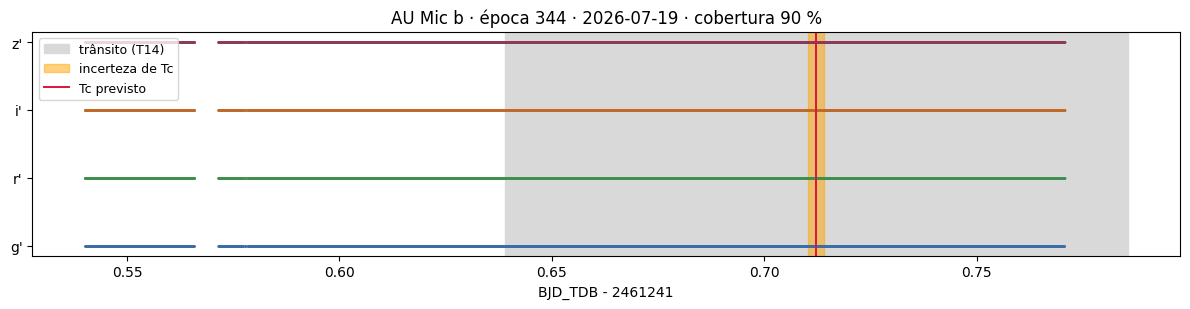

In [4]:
# ═══ 2 · previsão do trânsito e cobertura da observação ══════════════════════
import numpy as np, matplotlib.pyplot as plt
from astropy.time import Time

# época mais próxima do meio da observação
T_MID = 0.5 * (TSTART + TSTOP)
EPOCH = int(np.round((T_MID - T0_TDB) / PER))
TC    = T0_TDB + EPOCH * PER
TC_ERR = np.hypot(T0_ERR, EPOCH * PER_ERR)

# duração do trânsito a partir da geometria
b   = A_RS * np.cos(np.radians(INC))
arg = np.sqrt(max((1 + RP_RS) ** 2 - b ** 2, 0.0)) / (A_RS * np.sin(np.radians(INC)))
T14 = PER / np.pi * np.arcsin(min(arg, 1.0))
arg2 = np.sqrt(max((1 - RP_RS) ** 2 - b ** 2, 0.0)) / (A_RS * np.sin(np.radians(INC)))
T23 = PER / np.pi * np.arcsin(min(arg2, 1.0))

ING, EGR = TC - T14 / 2, TC + T14 / 2
cob = (min(TSTOP, EGR) - max(TSTART, ING)) / T14

print(f"época E = {EPOCH}")
print(f"Tc previsto = {TC:.6f} BJD_TDB  ± {TC_ERR*24*60:.2f} min   "
      f"({Time(TC, format='jd').isot} UTC)")
print(f"parâmetro de impacto b = {b:.3f}   T14 = {T14*24:.2f} h   T23 = {T23*24:.2f} h")
print(f"contato 1 (ingresso) = {ING:.6f}   contato 4 (egresso) = {EGR:.6f}")
print(f"\njanela observada     = {TSTART:.6f} .. {TSTOP:.6f}")
print(f"cobertura do trânsito = {cob*100:.1f} %  "
      f"({'PARCIAL' if cob < 0.99 else 'COMPLETO'})")
if TSTART > ING:
    print(f"  falta o início: {(TSTART-ING)*24*60:.1f} min antes do 1º contato")
if TSTOP < EGR:
    print(f"  falta o fim   : {(EGR-TSTOP)*24*60:.1f} min depois do 4º contato")
print(f"  baseline antes do ingresso : {(max(ING,TSTART)-TSTART)*24*60:.1f} min")
print(f"  baseline depois do egresso : {(TSTOP-min(EGR,TSTOP))*24*60:.1f} min")

# janela do trânsito usada nas máscaras (com folga)
FOLGA    = 15.0 / (24 * 60)          # 15 min de folga de cada lado
TRAN_WIN = (ING - FOLGA, EGR + FOLGA)

fig, ax = plt.subplots(figsize=(12, 3.2))
for ch, d in dados.items():
    ax.plot(d["t"] - T_REF, np.full(d["t"].size, ch), ".", ms=1,
            color=cols_b[d["band"]])
ax.axvspan(ING - T_REF, EGR - T_REF, color="0.85", zorder=0, label="trânsito (T14)")
ax.axvspan(TC - TC_ERR - T_REF, TC + TC_ERR - T_REF, color="orange", alpha=.5,
           zorder=1, label="incerteza de Tc")
ax.axvline(TC - T_REF, color="crimson", lw=1.4, label="Tc previsto")
ax.set_yticks(list(dados)); ax.set_yticklabels([f"{d['band']}'" for d in dados.values()])
ax.set_xlabel(f"BJD_TDB - {T_REF:.0f}")
ax.set_title(f"AU Mic b · época {EPOCH} · {NIGHT_LABEL} · cobertura {cob*100:.0f} %")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()



In [5]:
# ═══ 3 · escolha da abertura e das estrelas de comparação ═══════════════════
# A profundidade do trânsito (2,8 ppt) é menor que as sistemáticas típicas, então
# a abertura e o conjunto de comparações mudam o resultado. O critério usa SÓ o
# trecho FORA do trânsito: minimiza o resíduo em bins de BIN_OTIM minutos depois
# de remover uma linha de base (tempo + massa de ar). Como nenhum ponto dentro
# do trânsito entra no critério, a escolha não "cria" nem apaga o sinal.
import itertools
import numpy as np, pandas as pd

OTIMIZAR   = True      # False = usa APER_WANT e as NCOMPS mais brilhantes
BIN_OTIM   = 2.0       # minutos
N_CAND     = 6         # nº de candidatas a comparação (as mais brilhantes)
MAX_COMPS  = 4         # tamanho máximo do conjunto de comparações
BASE_OTIM  = 1         # ordem do polinômio temporal no critério

def _bin_med(t, y, dt_dias):
    """Binning por mediana, vetorizado."""
    k  = np.floor((t - t.min()) / dt_dias).astype(int)
    nb = k.max() + 1
    tb = np.bincount(k, t, nb) / np.maximum(np.bincount(k, None, nb), 1)
    yb = np.array([np.median(y[k == u]) if np.any(k == u) else np.nan
                   for u in range(nb)])
    ok = np.isfinite(tb) & np.isfinite(yb) & (np.bincount(k, None, nb) > 0)
    return tb[ok], yb[ok], k, ok

def _score(t, r, X, fora):
    """rms (ppt) do resíduo fora do trânsito depois da linha de base."""
    ok = np.isfinite(r) & fora
    if ok.sum() < 50:
        return np.inf
    tb, fb, _, _ = _bin_med(t[ok], r[ok] / np.median(r[ok]), BIN_OTIM / 1440)
    Xb, _, _, _  = _bin_med(t[ok], X[ok], BIN_OTIM / 1440)
    tn = (tb - TC) * 24
    D  = np.column_stack([np.ones_like(tn)] +
                         [tn ** k for k in range(1, BASE_OTIM + 1)] + [Xb - 1])
    if tb.size < D.shape[1] + 5:
        return np.inf
    c, *_ = np.linalg.lstsq(D, fb, rcond=None)
    return float(np.std(fb - D @ c) * 1e3)

def _razao(M, it, ic):
    with np.errstate(invalid="ignore", divide="ignore"):
        ft = 10 ** (-0.4 * M[it])
        fc = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        return ft / fc

if OTIMIZAR:
    escolha, linhas = {}, []
    for ch in sorted(dados):
        lf   = _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
        aps  = _aps(lf)
        best = None
        for aper in sorted(aps):
            t_utc, idx, A, hdr0 = load_cat(lf, aps[aper][0])
            t = para_tdb(t_utc);  X = massa_ar(t_utc, hdr0)
            fora = (t < ING) | (t > EGR)
            M = A["MAG"]
            ordem = idx[np.argsort(np.nanmedian(M, axis=1))]
            tgt   = int(ordem[0])
            it    = int(np.where(idx == tgt)[0][0])
            cand  = [int(i) for i in ordem[1:1 + N_CAND]]
            for n in range(1, MAX_COMPS + 1):
                for cs in itertools.combinations(cand, n):
                    ic = [int(np.where(idx == c)[0][0]) for c in cs]
                    s  = _score(t, _razao(M, it, ic), X, fora)
                    if best is None or s < best[0]:
                        best = (s, aper, tgt, list(cs))
            del A, M
        s, aper, tgt, cps = best
        escolha[ch] = dict(aper=aper, alvo=tgt, comps=cps, rms=s)
        linhas.append(dict(banda=f"{dados[ch]['band']}'", AP=aper, alvo=tgt,
                           comps=str(cps), rms_fora_ppt=s,
                           rms_antes_ppt=np.nan))
        print(f"c{ch} ({dados[ch]['band']}'): AP{aper:03d}  comps={cps}  "
              f"rms fora do trânsito = {s:.2f} ppt")

    # reconstrói `dados` com a configuração escolhida
    for ch, e in escolha.items():
        lf = _find(f"*_s4c{ch}_*_{BEAM}_lc.fits")
        cat = _aps(lf)[e["aper"]][0]
        t_utc, idx, A, hdr0 = load_cat(lf, cat)
        M, E = A["MAG"], A["EMAG"]
        it = int(np.where(idx == e["alvo"])[0][0])
        ic = [int(np.where(idx == c)[0][0]) for c in e["comps"]]
        k  = 0.4 * np.log(10)
        with np.errstate(invalid="ignore", divide="ignore"):
            ft, et = 10 ** (-0.4 * M[it]), k * 10 ** (-0.4 * M[it]) * E[it]
            fc = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
            ec = np.sqrt(np.nansum((k * 10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
            r  = ft / fc
            er = r * np.hypot(et / ft, ec / fc)
        ok = np.isfinite(r) & np.isfinite(er) & (er > 0)
        d  = dados[ch]
        d.update(aper=e["aper"], alvo=e["alvo"], comps=e["comps"],
                 t=para_tdb(t_utc)[ok], t_utc=t_utc[ok],
                 f=r[ok] / np.nanmedian(r[ok]), ef=er[ok] / np.nanmedian(r[ok]),
                 X=massa_ar(t_utc, hdr0)[ok],
                 fwhm=A["FWHM"][it][ok] if "FWHM" in A else np.full(ok.sum(), np.nan))

    tab_otim = pd.DataFrame(linhas).drop(columns="rms_antes_ppt").set_index("banda")
    print("\n── configuração escolhida " + "─" * 40)
    display(tab_otim.style.format({"rms_fora_ppt": "{:.2f}"}))
    print(f"para comparar: profundidade do trânsito = {RP_RS**2*1e3:.2f} ppt")
else:
    print("otimização desligada — usando APER_WANT e as NCOMPS mais brilhantes")


c1 (g'): AP008  comps=[1, 3, 2, 4]  rms fora do trânsito = 1.33 ppt
c2 (r'): AP008  comps=[1]  rms fora do trânsito = 2.29 ppt
c3 (i'): AP008  comps=[1]  rms fora do trânsito = 2.84 ppt
c4 (z'): AP008  comps=[1, 3]  rms fora do trânsito = 2.27 ppt

── configuração escolhida ────────────────────────────────────────


,AP,alvo,comps,rms_fora_ppt
banda,,,,
g',8,0,"[1, 3, 2, 4]",1.33
r',8,0,[1],2.29
i',8,0,[1],2.84
z',8,0,"[1, 3]",2.27


para comparar: profundidade do trânsito = 2.77 ppt


── ruído e variabilidade · bins de 2 min ──────────────────────────────


,n_pts,flares,n_bins,rms_pt_ppt,erro_form_ppt,ruido_bin_ppt,beta,amplitude_ppt
banda,,,,,,,,
g',7039,36,164,6.82,0.71,1.38,1.94,15.5
r',14077,113,164,16.19,0.96,1.75,1.82,16.6
i',14077,98,164,17.12,1.24,1.80,1.45,18.4
z',14075,70,164,15.59,1.39,1.72,1.24,19.5


profundidade esperada do trânsito: 2.77 ppt
A coluna 'amplitude' é a variação total da noite (estrela + massa de ar):
é ela que a linha de base precisa absorver para o trânsito aparecer.


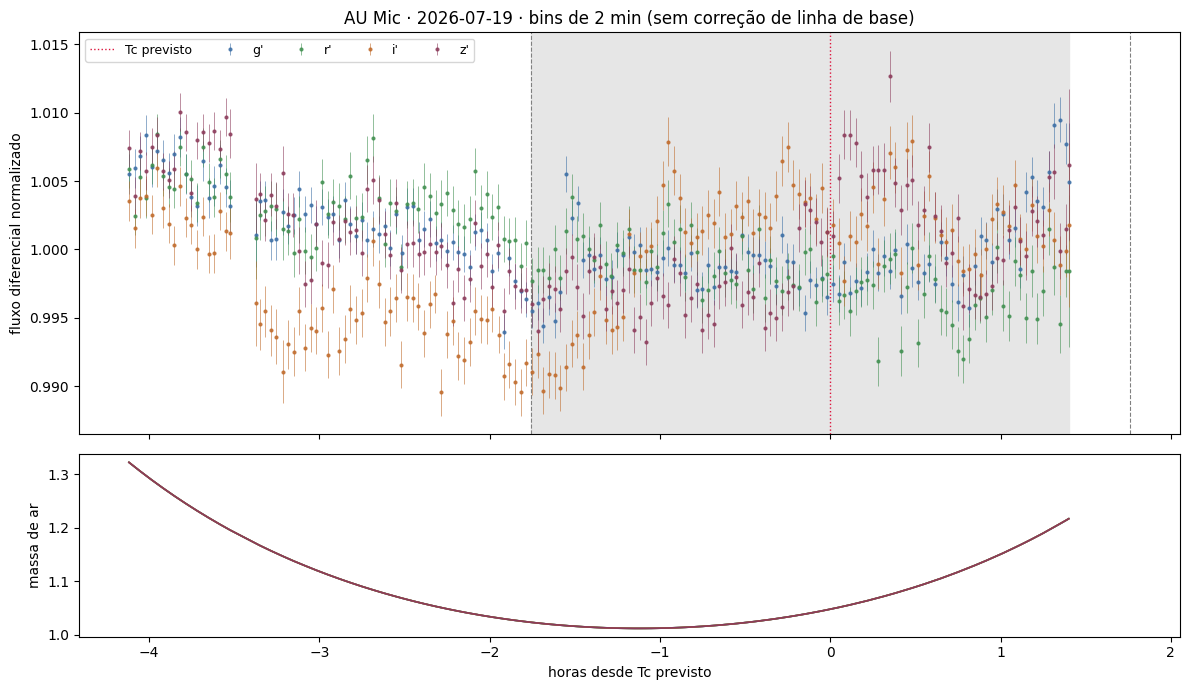

In [6]:
# ═══ 4 · máscara de flares, binning e ruído real por banda ══════════════════
# NÃO se corrige a linha de base aqui: sem base depois do egresso, remover a
# tendência antes do ajuste apagaria parte do trânsito. A linha de base entra
# como parâmetro livre junto com o modelo, na célula seguinte.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

BIN_MIN    = 2.0        # binning em minutos
NSIG_FLARE = 3.0        # corta excursões POSITIVAS acima deste nível
SUAVE_MIN  = 10.0       # janela (min) da mediana móvel usada na detecção

def med_movel(t, y, jan_dias):
    """Mediana móvel (janela em dias convertida para nº de pontos)."""
    from scipy.ndimage import median_filter
    cad = np.median(np.diff(t))
    n   = max(int(round(jan_dias / cad)), 3)
    n  += 1 - n % 2
    return median_filter(y, size=n, mode="nearest")

def binar(t, y, ey, dt_dias, extra=None):
    """Média ponderada em bins de dt_dias. extra = dict de colunas a mediar."""
    if not dt_dias:
        return t, y, ey, np.ones_like(t), {k: v for k, v in (extra or {}).items()}
    k = np.floor((t - t.min()) / dt_dias).astype(int)
    tb, yb, eb, nb = [], [], [], []
    ex = {c: [] for c in (extra or {})}
    for gidx in np.unique(k):
        m = k == gidx
        if m.sum() == 0:
            continue
        w = 1 / ey[m] ** 2
        tb.append(np.average(t[m], weights=w))
        yb.append(np.average(y[m], weights=w))
        eb.append(np.sqrt(1 / w.sum()))
        nb.append(int(m.sum()))
        for c, v in (extra or {}).items():
            ex[c].append(np.mean(v[m]))
    return (np.array(tb), np.array(yb), np.array(eb), np.array(nb),
            {c: np.array(v) for c, v in ex.items()})

linhas = []
for ch, d in dados.items():
    t, f, ef, X = d["t"], d["f"], d["ef"], d["X"]

    suave = med_movel(t, f, SUAVE_MIN / (24 * 60))
    resid = f - suave
    sig   = 1.4826 * np.median(np.abs(resid - np.median(resid)))
    flare = resid > NSIG_FLARE * sig
    keep  = (~flare) & np.isfinite(f)

    tb, fb, eb, nb, ex = binar(t[keep], f[keep], ef[keep], BIN_MIN / (24 * 60),
                               extra={"X": X[keep]})
    med = np.median(fb)
    fb, eb = fb / med, eb / med

    # ruído branco real no bin: dispersão entre bins vizinhos / sqrt(2)
    sig_bin = np.std(np.diff(fb)) / np.sqrt(2)
    beta    = sig_bin / np.mean(eb)          # quanto o erro formal subestima
    eb_infl = np.maximum(eb * beta, eb)

    d.update(flare=flare, tb=tb, fb=fb, eb=eb_infl, eb_form=eb, nb=nb,
             Xb=ex["X"], sig_bin=sig_bin, beta=beta)
    linhas.append(dict(banda=f"{d['band']}'", n_pts=int(t.size),
                       flares=int(flare.sum()), n_bins=int(tb.size),
                       rms_pt_ppt=np.std(f[keep]) * 1e3,
                       erro_form_ppt=np.mean(eb) * 1e3,
                       ruido_bin_ppt=sig_bin * 1e3, beta=beta,
                       amplitude_ppt=(fb.max() - fb.min()) * 1e3))

tab_ruido = pd.DataFrame(linhas).set_index("banda")
print(f"── ruído e variabilidade · bins de {BIN_MIN:.0f} min " + "─" * 30)
display(tab_ruido.style.format({"rms_pt_ppt": "{:.2f}", "erro_form_ppt": "{:.2f}",
                                "ruido_bin_ppt": "{:.2f}", "beta": "{:.2f}",
                                "amplitude_ppt": "{:.1f}"}))
print(f"profundidade esperada do trânsito: {RP_RS**2*1e3:.2f} ppt")
print("A coluna 'amplitude' é a variação total da noite (estrela + massa de ar):\n"
      "é ela que a linha de base precisa absorver para o trânsito aparecer.")

fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                        gridspec_kw=dict(height_ratios=[2.2, 1]))
for ch, d in dados.items():
    axs[0].errorbar((d["tb"] - TC) * 24, d["fb"], d["eb"], fmt=".", ms=4, lw=.5,
                    alpha=.8, color=cols_b[d["band"]], label=f"{d['band']}'")
    axs[1].plot((d["tb"] - TC) * 24, d["Xb"], "-", lw=1.2, color=cols_b[d["band"]])
for x, lab in [((ING - TC) * 24, "1º contato"), ((EGR - TC) * 24, "4º contato")]:
    axs[0].axvline(x, color="0.5", lw=.8, ls="--")
axs[0].axvline(0, color="crimson", lw=1.0, ls=":", label="Tc previsto")
axs[0].axvspan((max(TSTART, ING) - TC) * 24, (min(TSTOP, EGR) - TC) * 24,
               color="0.9", zorder=0)
axs[0].set_ylabel("fluxo diferencial normalizado")
axs[0].legend(ncol=5, fontsize=9)
axs[0].set_title(f"AU Mic · {NIGHT_LABEL} · bins de {BIN_MIN:.0f} min "
                 f"(sem correção de linha de base)")
axs[1].set_ylabel("massa de ar");  axs[1].set_xlabel("horas desde Tc previsto")
plt.tight_layout();  plt.show()



χ²/ndof = 1664.6/639 = 2.61   (erros inflados por √2.61 = 1.61)
Δχ² contra 'sem trânsito' = 31.4  ->  -5.6σ  (CLAREAMENTO no lugar do trânsito — sistemática)

Tc previsto  = 2461241.712289 BJD_TDB  ± 2.69 min (efeméride)
Tc ajustado  = 2461241.716803 BJD_TDB
O-C          = +6.50  -2.50/+>3.5 min   (Δχ²=1 não fecha dentro da varredura: Tc mal determinado)


,AP,prof (ppt),sig_prof (ppt),SNR,Rp/R*,sig_Rp/R*,rms res (ppt),n bins
banda,,,,,,,,
g',8,-3.09,0.55,-5.6,nan,nan,2.14,164
r',8,-3.02,0.54,-5.6,nan,nan,2.19,164
i',8,-2.85,0.51,-5.6,nan,nan,3.29,164
z',8,-2.74,0.49,-5.6,nan,nan,3.00,164


literatura: Rp/R* = 0.0526  ->  profundidade 3.67 ppt (com escurecimento de bordo em g')

AVISO: trânsito parcial (90 % de T14, sem linha de base
depois do egresso). Profundidade e tendência ficam correlacionadas;
a barra de erro acima já inclui essa correlação, mas o resultado
depende de BASE_ORD e de USA_MASSA — vale repetir com 1 e 2.


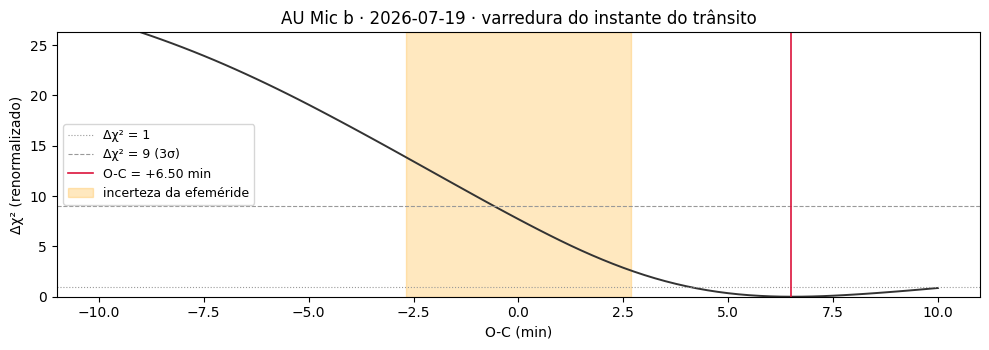

In [8]:
# ═══ 5 · ajuste: varredura em Tc + solução linear da profundidade ═══════════
# Num trânsito parcial a profundidade é degenerada com a tendência, e um
# otimizador não-linear cai fácil em rp = 0. Aqui a linha de base e a
# profundidade entram JUNTAS num sistema linear (a profundidade é pequena, ~ppt,
# então  base × trânsito ≃ base − δ·forma  com erro < 0.1 ppt), e o único
# parâmetro não-linear, Tc, é varrido numa grade. Sai o χ²(Tc) inteiro, e não
# só um mínimo local.
import numpy as np, pandas as pd, batman

RP_COMUM  = True     # uma profundidade comum às 4 bandas; False = por banda
DT_MAX    = 10.0     # varredura de Tc em ± minutos (a efeméride prevê Tc
                     # com ~2.7 min; varrer muito mais larga só acha ruído)
DT_PASSO  = 0.25     # passo da varredura, em minutos
BASE_ORD  = 2        # ordem do polinômio temporal da linha de base
USA_MASSA = True     # inclui termo linear em (massa de ar - 1)
SUPER     = True     # amostra o modelo dentro do bin

chs    = sorted(dados)
bandas = [dados[ch]["band"] for ch in chs]
exp_d  = BIN_MIN / (24 * 60)

def _params(tc, rp, band):
    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = tc, PER, abs(rp), A_RS, INC
    p.ecc, p.w = ECC, W
    p.u, p.limb_dark = list(LDC[band]), "quadratic"
    return p

_MOD = {}
def modelo_banda(t, tc, rp, band, exp_dias=exp_d):
    """batman com o TransitModel reaproveitado por grade de tempo."""
    t = np.asarray(t, float)
    key = (band, t.size, float(t[0]), float(t[-1]), float(exp_dias))
    p = _params(tc, rp, band)
    if key not in _MOD:
        sup = 7 if (SUPER and exp_dias > 0) else 1
        _MOD[key] = batman.TransitModel(
            p, t, supersample_factor=sup,
            exp_time=exp_dias if sup > 1 else 0.0)
    return _MOD[key].light_curve(p)

# profundidade de referência do modelo (no centro, em grade fina)
_tf   = np.linspace(TC - T14, TC + T14, 3000)
PROF0 = {b: 1 - modelo_banda(_tf, TC, RP_RS, b, 0.0).min() for b in bandas}

def forma(t, tc, band):
    """Trânsito da literatura como perfil: 0 fora, PROF0 no centro.
    O parâmetro ajustado (delta) é a ESCALA desse perfil: delta = 1 significa
    exatamente a profundidade da literatura, e a razão entre as bandas (dada
    pelo escurecimento de bordo) é preservada."""
    return 1 - modelo_banda(t, tc, RP_RS, band)

# ── desenho da linha de base por banda ───────────────────────────────────────
def _design(d):
    tn   = (d["tb"] - TC) * 24.0                    # horas desde Tc previsto
    cols = [np.ones_like(tn)] + [tn ** k for k in range(1, BASE_ORD + 1)]
    if USA_MASSA:
        cols.append(d["Xb"] - 1.0)
    return np.column_stack(cols)

DES = {ch: _design(dados[ch]) for ch in chs}
NB  = DES[chs[0]].shape[1]
n_d = 1 if RP_COMUM else len(chs)
NP  = len(chs) * NB + n_d          # nº de parâmetros do sistema linear

def resolve(dt_min, com_transito=True):
    """Resolve base (+ profundidade) para um Tc; devolve chi2, params, cov."""
    tc = TC + dt_min / (24 * 60)
    npar = NP if com_transito else len(chs) * NB
    G = np.zeros((sum(dados[ch]["tb"].size for ch in chs), npar))
    y = np.zeros(G.shape[0]);  w = np.zeros(G.shape[0])
    i0 = 0
    for j, ch in enumerate(chs):
        d  = dados[ch];  n = d["tb"].size;  sl = slice(i0, i0 + n)
        G[sl, j * NB:(j + 1) * NB] = DES[ch]
        if com_transito:
            k = len(chs) * NB + (0 if RP_COMUM else j)
            G[sl, k] = -forma(d["tb"], tc, d["band"])
        y[sl] = d["fb"];  w[sl] = 1 / d["eb"]
        i0 += n
    Gw, yw = G * w[:, None], y * w
    par, *_ = np.linalg.lstsq(Gw, yw, rcond=None)
    chi2 = float(np.sum((Gw @ par - yw) ** 2))
    cov  = np.linalg.pinv(Gw.T @ Gw)
    return chi2, par, cov, G, y, w

# ── varredura em Tc ──────────────────────────────────────────────────────────
dts   = np.arange(-DT_MAX, DT_MAX + DT_PASSO / 2, DT_PASSO)
chi2s = np.array([resolve(dt)[0] for dt in dts])
k_best = int(np.argmin(chi2s))
dt_min_fit = float(dts[k_best])

chi2, par, cov, G, y, w = resolve(dt_min_fit)
ndof   = G.shape[0] - NP
esc    = max(chi2 / ndof, 1.0)                    # inflaciona erros correlacionados
cov   *= esc
err    = np.sqrt(np.abs(np.diag(cov)))

bas_fit = par[:len(chs) * NB].reshape(len(chs), NB)
delta   = par[len(chs) * NB:]                     # profundidade em unidades de PROF0
e_delta = err[len(chs) * NB:]

# incerteza de Tc: Δχ² = 1 na curva varrida (renormalizada por chi2_red)
c_norm = (chi2s - chi2s[k_best]) / esc
i_e = np.where(c_norm[:k_best] > 1)[0]
i_d = np.where(c_norm[k_best + 1:] > 1)[0]
e_dt_m = dt_min_fit - dts[i_e[-1]] if i_e.size else np.nan
e_dt_p = dts[k_best + 1 + i_d[0]] - dt_min_fit if i_d.size else np.nan
e_dt   = np.nanmean([e_dt_m, e_dt_p])

dt_fit  = dt_min_fit / (24 * 60)
TC_OBS  = TC + dt_fit

# modelo sem trânsito, no mesmo Tc
chi2_0 = resolve(dt_min_fit, com_transito=False)[0]
dchi2  = (chi2_0 - chi2) / esc
# significância COM SINAL: delta < 0 significa que o ajuste prefere um
# clareamento no lugar do trânsito, o que é sinal de sistemática, não detecção
nsig   = float(np.sign(np.mean(delta)) * np.sqrt(max(dchi2, 0.0)))

# profundidades e raios
prof_b  = np.array([delta[0 if RP_COMUM else j] * PROF0[bandas[j]]
                    for j in range(len(chs))])
eprof_b = np.array([e_delta[0 if RP_COMUM else j] * PROF0[bandas[j]]
                    for j in range(len(chs))])
# Rp/R* só faz sentido se a profundidade for positiva
rp_fit  = np.where(delta > 0, RP_RS * np.sqrt(np.clip(delta, 0, None)), np.nan)
erp_fit = np.where(delta > 0,
                   RP_RS * 0.5 * e_delta / np.sqrt(np.clip(delta, 1e-9, None)), np.nan)

mod_fit, base_fit = {}, {}
for j, ch in enumerate(chs):
    d = dados[ch]
    base_fit[ch] = DES[ch] @ bas_fit[j]
    mod_fit[ch]  = base_fit[ch] - delta[0 if RP_COMUM else j] * \
                   forma(d["tb"], TC_OBS, d["band"])

print(f"χ²/ndof = {chi2:.1f}/{ndof} = {chi2/ndof:.2f}   "
      f"(erros inflados por √{esc:.2f} = {np.sqrt(esc):.2f})")
_veredito = ("detecção do trânsito" if nsig > 3 else
             "CLAREAMENTO no lugar do trânsito — sistemática" if nsig < -3 else
             "sem detecção significativa")
print(f"Δχ² contra 'sem trânsito' = {dchi2:.1f}  ->  {nsig:+.1f}σ  ({_veredito})")
print(f"\nTc previsto  = {TC:.6f} BJD_TDB  ± {TC_ERR*24*60:.2f} min (efeméride)")
print(f"Tc ajustado  = {TC_OBS:.6f} BJD_TDB")
_em = f"{e_dt_m:.2f}" if np.isfinite(e_dt_m) else f">{DT_MAX - abs(dt_min_fit):.1f}"
_ep = f"{e_dt_p:.2f}" if np.isfinite(e_dt_p) else f">{DT_MAX - abs(dt_min_fit):.1f}"
print(f"O-C          = {dt_min_fit:+.2f}  -{_em}/+{_ep} min"
      + ("   (Δχ²=1 não fecha dentro da varredura: Tc mal determinado)"
         if not (np.isfinite(e_dt_m) and np.isfinite(e_dt_p)) else ""))

linhas = []
for j, ch in enumerate(chs):
    d = dados[ch]
    res = d["fb"] - mod_fit[ch]
    linhas.append({"banda": f"{d['band']}'", "AP": d["aper"],
                   "prof (ppt)": prof_b[j] * 1e3,
                   "sig_prof (ppt)": eprof_b[j] * 1e3,
                   "SNR": prof_b[j] / eprof_b[j] if eprof_b[j] > 0 else np.nan,
                   "Rp/R*": float(rp_fit[0 if RP_COMUM else j]),
                   "sig_Rp/R*": float(erp_fit[0 if RP_COMUM else j]),
                   "rms res (ppt)": np.std(res) * 1e3,
                   "n bins": int(d["tb"].size)})
tab_fit = pd.DataFrame(linhas).set_index("banda")
display(tab_fit.style.format({"prof (ppt)": "{:.2f}", "sig_prof (ppt)": "{:.2f}",
                              "SNR": "{:.1f}", "Rp/R*": "{:.4f}",
                              "sig_Rp/R*": "{:.4f}", "rms res (ppt)": "{:.2f}"}))
print(f"literatura: Rp/R* = {RP_RS:.4f}  ->  profundidade "
      f"{PROF0[bandas[0]]*1e3:.2f} ppt (com escurecimento de bordo em "
      f"{bandas[0]}')")
if cob < 0.99:
    print(f"\nAVISO: trânsito parcial ({cob*100:.0f} % de T14, sem linha de base\n"
          f"depois do egresso). Profundidade e tendência ficam correlacionadas;\n"
          f"a barra de erro acima já inclui essa correlação, mas o resultado\n"
          f"depende de BASE_ORD e de USA_MASSA — vale repetir com 1 e 2.")

# ── curva de χ²(Tc) ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3.6))
plt.plot(dts, c_norm, "-", lw=1.4, color="#333")
plt.axhline(1, color="0.6", lw=.8, ls=":", label="Δχ² = 1")
plt.axhline(9, color="0.6", lw=.8, ls="--", label="Δχ² = 9 (3σ)")
plt.axvline(dt_min_fit, color="crimson", lw=1.2, label=f"O-C = {dt_min_fit:+.2f} min")
plt.axvspan(-TC_ERR * 24 * 60, TC_ERR * 24 * 60, color="orange", alpha=.25,
            label="incerteza da efeméride")
plt.xlabel("O-C (min)");  plt.ylabel("Δχ² (renormalizado)")
plt.title(f"AU Mic b · {NIGHT_LABEL} · varredura do instante do trânsito")
plt.legend(fontsize=9);  plt.ylim(0, max(20, np.nanpercentile(c_norm, 95)))
plt.tight_layout();  plt.show()


In [9]:
# ═══ 6 · robustez: o resultado depende da linha de base? ════════════════════
# Teste decisivo num trânsito parcial. Repete o ajuste variando a ordem do
# polinômio, o termo de massa de ar e a janela de tempo usada. Se profundidade
# e O-C mudarem de sinal ou pularem para os limites da varredura, o que está
# sendo medido é ruído correlacionado, não o trânsito.
import numpy as np, pandas as pd

ORDENS  = [1, 2, 3]
MASSAS  = [True, False]
JANELAS = [None, 3.5, 2.5]      # horas em torno de Tc (None = noite inteira)

def _ajuste_cfg(ordem, massa, jan_h, dts=None):
    dts = np.arange(-DT_MAX, DT_MAX + 1e-9, DT_PASSO) if dts is None else dts
    sel = {ch: (np.ones(dados[ch]["tb"].size, bool) if jan_h is None else
                np.abs(dados[ch]["tb"] - TC) * 24 <= jan_h) for ch in chs}
    NBl = 1 + ordem + (1 if massa else 0)

    def resolve(dt, com=True):
        tc = TC + dt / (24 * 60)
        n  = sum(int(sel[ch].sum()) for ch in chs)
        G  = np.zeros((n, len(chs) * NBl + (1 if com else 0)))
        y  = np.zeros(n);  w = np.zeros(n);  i0 = 0
        for j, ch in enumerate(chs):
            d, m = dados[ch], sel[ch];  k = int(m.sum());  sl = slice(i0, i0 + k)
            tn   = (d["tb"][m] - TC) * 24
            cols = [np.ones_like(tn)] + [tn ** q for q in range(1, ordem + 1)]
            if massa:
                cols.append(d["Xb"][m] - 1)
            G[sl, j * NBl:(j + 1) * NBl] = np.column_stack(cols)
            if com:
                G[sl, -1] = -forma(d["tb"][m], tc, d["band"])
            y[sl], w[sl] = d["fb"][m], 1 / d["eb"][m]
            i0 += k
        Gw, yw = G * w[:, None], y * w
        par, *_ = np.linalg.lstsq(Gw, yw, rcond=None)
        c2  = float(np.sum((Gw @ par - yw) ** 2))
        return c2, par, np.linalg.pinv(Gw.T @ Gw), G.shape[0] - G.shape[1]

    c2s = np.array([resolve(dt)[0] for dt in dts])
    kb  = int(np.argmin(c2s))
    c2, par, cov, ndof = resolve(dts[kb])
    esc = max(c2 / ndof, 1.0)
    dl, edl = par[-1], np.sqrt(abs(cov[-1, -1]) * esc)
    d2  = (resolve(dts[kb], com=False)[0] - c2) / esc
    return dict(base=f"poly{ordem}" + ("+massa" if massa else ""),
                janela=("noite" if jan_h is None else f"±{jan_h:.1f} h"),
                oc_min=float(dts[kb]),
                prof_ppt=float(dl * PROF0[bandas[0]] * 1e3),
                sig_ppt=float(edl * PROF0[bandas[0]] * 1e3),
                nsig=float(np.sign(dl) * np.sqrt(max(d2, 0.0))),
                chi2r=float(c2 / ndof))

rob = pd.DataFrame([_ajuste_cfg(o, m, j)
                    for o in ORDENS for m in MASSAS for j in JANELAS])
display(rob.style.format({"oc_min": "{:+.2f}", "prof_ppt": "{:+.2f}",
                          "sig_ppt": "{:.2f}", "nsig": "{:+.1f}",
                          "chi2r": "{:.2f}"}))

p_med, p_std = rob["prof_ppt"].mean(), rob["prof_ppt"].std()
mesmo_sinal  = bool(np.all(np.sign(rob["prof_ppt"]) == np.sign(rob["prof_ppt"].iloc[0])))
nos_limites  = int((np.abs(rob["oc_min"]) > 0.95 * DT_MAX).sum())

print(f"\nprofundidade entre configurações: {rob['prof_ppt'].min():+.2f} a "
      f"{rob['prof_ppt'].max():+.2f} ppt   (média {p_med:+.2f}, dispersão {p_std:.2f})")
print(f"O-C encostando no limite da varredura em {nos_limites}/{len(rob)} casos")
print(f"esperado pela literatura: {PROF0[bandas[0]]*1e3:+.2f} ppt "
      f"(sempre positiva)\n")

if (not mesmo_sinal) or p_std > abs(p_med) or nos_limites > len(rob) / 3:
    print("VEREDITO: resultado NÃO robusto. A profundidade muda de sinal ou de\n"
          "valor conforme a linha de base, e o O-C pula para os extremos: o\n"
          "ajuste está seguindo ruído correlacionado (variabilidade da estrela +\n"
          "sistemática de massa de ar), que nesta noite é da ordem de alguns ppt,\n"
          "ou seja, do tamanho do próprio trânsito.\n"
          "  -> trate como NÃO DETECÇÃO e use o limite superior abaixo.\n"
          "  -> caminhos para melhorar: (a) mais estrelas de comparação ou\n"
          "     comparações de cor mais parecida com AU Mic; (b) reduzir com\n"
          "     abertura ótima por imagem; (c) modelar a variabilidade com GP\n"
          "     (celerite2) em vez de polinômio; (d) combinar com outras noites.")
else:
    print("VEREDITO: profundidade estável entre as configurações — o valor da\n"
          "célula anterior pode ser usado, com a barra de erro já inflada.")

# limite superior (3σ) na profundidade, a partir da dispersão entre configurações
lim3 = 3 * max(rob["sig_ppt"].max(), p_std)
print(f"\nlimite superior conservador (3σ): profundidade < {lim3:.2f} ppt  "
      f"->  Rp/R* < {RP_RS*np.sqrt(lim3/(PROF0[bandas[0]]*1e3)):.4f}")


,base,janela,oc_min,prof_ppt,sig_ppt,nsig,chi2r
0,poly1+massa,noite,+7.00,-2.88,0.51,-5.6,2.78
1,poly1+massa,±3.5 h,+7.25,-2.44,0.58,-4.2,2.54
2,poly1+massa,±2.5 h,+5.50,-5.88,0.97,-6.1,2.41
3,poly1,noite,+10.00,-3.44,0.64,-5.4,4.30
4,poly1,±3.5 h,-10.00,+2.54,0.49,+5.2,3.03
5,poly1,±2.5 h,-10.00,+1.84,0.51,+3.6,3.02
6,poly2+massa,noite,+6.50,-3.09,0.55,-5.6,2.61
7,poly2+massa,±3.5 h,+6.75,-2.71,0.55,-4.9,2.29
8,poly2+massa,±2.5 h,+5.00,-6.76,0.91,-7.4,2.07
9,poly2,noite,+6.50,-3.11,0.51,-6.1,2.77



profundidade entre configurações: -6.76 a +2.54 ppt   (média -3.52, dispersão 2.53)
O-C encostando no limite da varredura em 3/18 casos
esperado pela literatura: +3.67 ppt (sempre positiva)

VEREDITO: resultado NÃO robusto. A profundidade muda de sinal ou de
valor conforme a linha de base, e o O-C pula para os extremos: o
ajuste está seguindo ruído correlacionado (variabilidade da estrela +
sistemática de massa de ar), que nesta noite é da ordem de alguns ppt,
ou seja, do tamanho do próprio trânsito.
  -> trate como NÃO DETECÇÃO e use o limite superior abaixo.
  -> caminhos para melhorar: (a) mais estrelas de comparação ou
     comparações de cor mais parecida com AU Mic; (b) reduzir com
     abertura ótima por imagem; (c) modelar a variabilidade com GP
     (celerite2) em vez de polinômio; (d) combinar com outras noites.

limite superior conservador (3σ): profundidade < 7.59 ppt  ->  Rp/R* < 0.0756


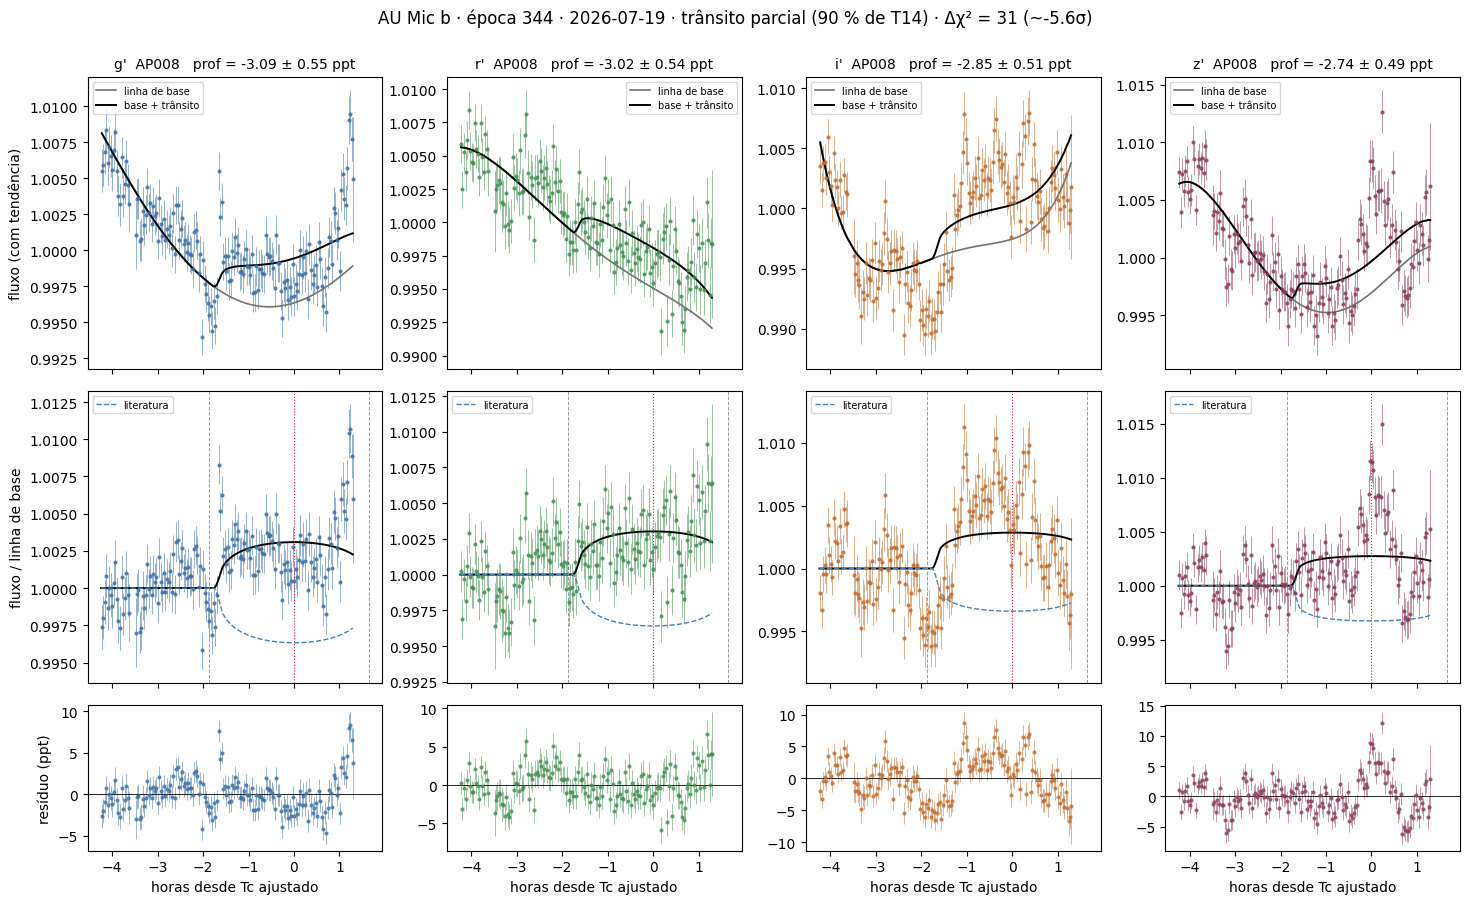

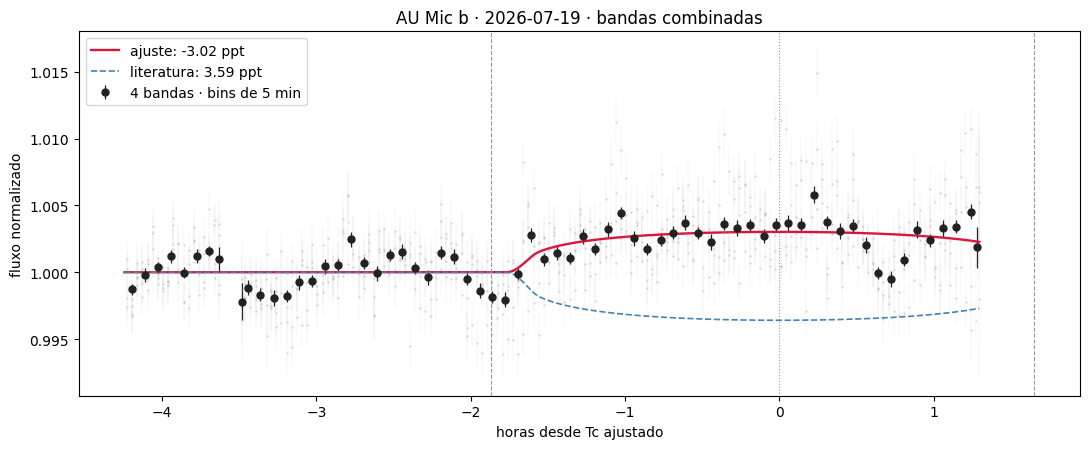

In [10]:
# ═══ 7 · figuras do ajuste ══════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt

tg = np.linspace(TSTART, TSTOP, 1500)

fig, axs = plt.subplots(3, len(chs), figsize=(3.7 * len(chs), 9), sharex=True,
                        gridspec_kw=dict(height_ratios=[2, 2, 1]))
axs = np.atleast_2d(axs).reshape(3, -1)
for j, ch in enumerate(chs):
    d   = dados[ch]
    dl  = float(delta[0 if RP_COMUM else j])
    x   = (d["tb"] - TC_OBS) * 24
    xg  = (tg - TC_OBS) * 24

    axs[0, j].errorbar(x, d["fb"], d["eb"], fmt=".", ms=4, lw=.5, alpha=.75,
                       color=cols_b[d["band"]])
    axs[0, j].plot(x, base_fit[ch], "-", lw=1.2, color="0.45", label="linha de base")
    axs[0, j].plot(x, mod_fit[ch], "-", lw=1.4, color="k", label="base + trânsito")
    axs[0, j].set_title(f"{d['band']}'  AP{d['aper']:03d}   "
                        f"prof = {prof_b[j]*1e3:.2f} ± {eprof_b[j]*1e3:.2f} ppt",
                        fontsize=10)
    axs[0, j].legend(fontsize=7)

    axs[1, j].errorbar(x, d["fb"] / base_fit[ch], d["eb"], fmt=".", ms=4, lw=.5,
                       alpha=.75, color=cols_b[d["band"]])
    axs[1, j].plot(xg, 1 - dl * forma(tg, TC_OBS, d["band"]), "k-", lw=1.4)
    axs[1, j].plot(xg, 1 - forma(tg, TC_OBS, d["band"]), "--", lw=1.0,
                   color="steelblue", label="literatura")
    for xv in [(ING - TC_OBS) * 24, (EGR - TC_OBS) * 24]:
        axs[1, j].axvline(xv, color="0.6", lw=.7, ls="--")
    axs[1, j].axvline(0, color="crimson", lw=.8, ls=":")
    axs[1, j].legend(fontsize=7)

    axs[2, j].errorbar(x, (d["fb"] - mod_fit[ch]) * 1e3, d["eb"] * 1e3, fmt=".",
                       ms=4, lw=.5, alpha=.7, color=cols_b[d["band"]])
    axs[2, j].axhline(0, color="k", lw=.6)
    axs[2, j].set_xlabel("horas desde Tc ajustado")
axs[0, 0].set_ylabel("fluxo (com tendência)")
axs[1, 0].set_ylabel("fluxo / linha de base")
axs[2, 0].set_ylabel("resíduo (ppt)")
fig.suptitle(f"AU Mic b · época {EPOCH} · {NIGHT_LABEL} · trânsito "
             f"{'parcial' if cob < 0.99 else 'completo'} ({cob*100:.0f} % de T14) · "
             f"Δχ² = {dchi2:.0f} (~{nsig:.1f}σ)", y=1.0)
plt.tight_layout();  plt.show()

# ── bandas combinadas, já divididas pela linha de base ──────────────────────
tt = np.concatenate([dados[ch]["tb"] for ch in chs])
ff = np.concatenate([dados[ch]["fb"] / base_fit[ch] for ch in chs])
ee = np.concatenate([dados[ch]["eb"] for ch in chs])
o  = np.argsort(tt);  tt, ff, ee = tt[o], ff[o], ee[o]
tb2, fb2, eb2, _, _ = binar(tt, ff, ee, 5.0 / (24 * 60))

dl_m = float(np.mean(delta))
plt.figure(figsize=(11, 4.6))
plt.errorbar((tt - TC_OBS) * 24, ff, ee, fmt=".", ms=2, lw=.3, alpha=.2, color="0.6")
plt.errorbar((tb2 - TC_OBS) * 24, fb2, eb2, fmt="o", ms=5, lw=.9, color="#222",
             label="4 bandas · bins de 5 min")
plt.plot((tg - TC_OBS) * 24, 1 - dl_m * forma(tg, TC_OBS, "r"), "-", lw=1.7,
         color="crimson",
         label=f"ajuste: {dl_m*PROF0['r']*1e3:.2f} ppt")
plt.plot((tg - TC_OBS) * 24, 1 - forma(tg, TC_OBS, "r"), "--", lw=1.2,
         color="steelblue", label=f"literatura: {PROF0['r']*1e3:.2f} ppt")
for xv in [(ING - TC_OBS) * 24, (EGR - TC_OBS) * 24]:
    plt.axvline(xv, color="0.6", lw=.8, ls="--")
plt.axvline(0, color="0.6", lw=.8, ls=":")
plt.xlabel("horas desde Tc ajustado");  plt.ylabel("fluxo normalizado")
plt.title(f"AU Mic b · {NIGHT_LABEL} · bandas combinadas")
plt.legend();  plt.tight_layout();  plt.show()



MCMC: 32 walkers × 4000 passos -> 9600 amostras | aceitação 0.72


,mediana,sig_menos,sig_mais
parametro,,,
O-C (min),3.6972,1.6692,1.7137
profundidade todas (ppt),-3.0008,0.5598,0.5628
Rp/R* todas,nan,nan,nan



Tc (MCMC) = 2461241.714857 BJD_TDB  [-1.67 / +1.71 min]
fração da posterior com profundidade > 0: 0.0 %


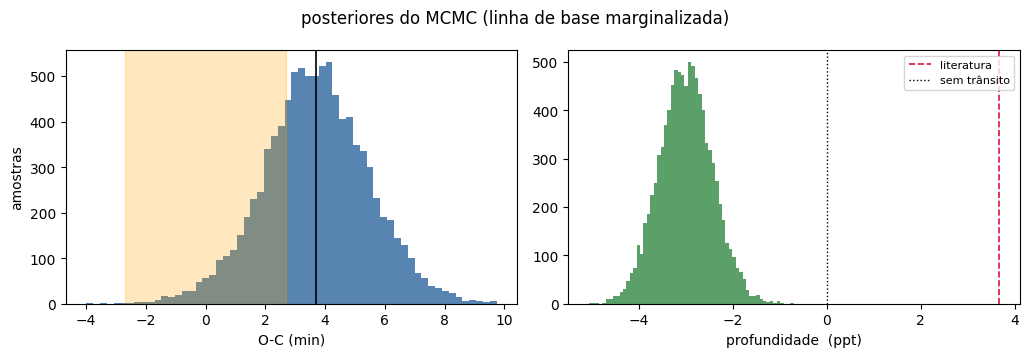

In [11]:
# ═══ 8 · MCMC (emcee): posterior de Tc e da profundidade ════════════════════
# Amostra só os parâmetros de interesse (O-C e profundidade); a linha de base é
# resolvida analiticamente a cada passo (perfil), o que deixa a cadeia curta e
# bem misturada. A profundidade pode ficar NEGATIVA de propósito: é assim que
# se vê se a detecção é real ou compatível com zero.
RUN_MCMC = True
NSTEP, NBURN, THIN = 4000, 1000, 10

if RUN_MCMC:
    import emcee, numpy as np, pandas as pd, matplotlib.pyplot as plt

    # projetor que remove a linha de base: chi2 = |R y|², sem resolver o
    # sistema a cada passo (a matriz da base não muda, só o vetor de dados)
    _W, _R = {}, {}
    for ch in chs:
        w  = 1 / dados[ch]["eb"]
        Gw = DES[ch] * w[:, None]
        _W[ch] = w
        _R[ch] = np.eye(w.size) - Gw @ np.linalg.pinv(Gw)

    def chi2_perfil(dt_min, deltas):
        tc, c2 = TC + dt_min / (24 * 60), 0.0
        for j, ch in enumerate(chs):
            d  = dados[ch]
            dl = deltas[0 if RP_COMUM else j]
            yw = (d["fb"] + dl * forma(d["tb"], tc, d["band"])) * _W[ch]
            c2 += float(yw @ (_R[ch] @ yw))
        return c2

    ndim  = 1 + n_d
    nwalk = 32

    # prior gaussiano no O-C, dado pela incerteza da própria efeméride
    SIG_OC = TC_ERR * 24 * 60          # minutos
    USA_PRIOR_OC = True

    def log_prob(p):
        if abs(p[0]) > DT_MAX or np.any(np.abs(p[1:]) > 4):
            return -np.inf
        lp = -0.5 * chi2_perfil(p[0], p[1:]) / esc
        if USA_PRIOR_OC:
            lp += -0.5 * (p[0] / SIG_OC) ** 2
        return lp

    p0 = np.concatenate([[dt_min_fit], np.atleast_1d(delta)])
    ini = p0 + np.random.randn(nwalk, ndim) * np.array([0.5] + [0.05] * n_d)
    sam = emcee.EnsembleSampler(nwalk, ndim, log_prob)
    sam.run_mcmc(ini, NSTEP, progress=False)
    cad = sam.get_chain(discard=NBURN, thin=THIN, flat=True)
    print(f"MCMC: {nwalk} walkers × {NSTEP} passos -> {cad.shape[0]} amostras | "
          f"aceitação {np.mean(sam.acceptance_fraction):.2f}")

    q = np.percentile(cad, [16, 50, 84], axis=0)
    lin = [dict(parametro="O-C (min)", mediana=q[1, 0],
                sig_menos=q[1, 0] - q[0, 0], sig_mais=q[2, 0] - q[1, 0])]
    for j in range(n_d):
        rot = "todas" if RP_COMUM else bandas[j]
        p0_ = PROF0[bandas[0] if RP_COMUM else bandas[j]]
        lin.append(dict(parametro=f"profundidade {rot} (ppt)",
                        mediana=q[1, 1 + j] * p0_ * 1e3,
                        sig_menos=(q[1, 1 + j] - q[0, 1 + j]) * p0_ * 1e3,
                        sig_mais=(q[2, 1 + j] - q[1, 1 + j]) * p0_ * 1e3))
        _r = lambda v: RP_RS * np.sqrt(v) if v > 0 else np.nan   # só faz sentido > 0
        lin.append(dict(parametro=f"Rp/R* {rot}",
                        mediana=_r(q[1, 1 + j]),
                        sig_menos=_r(q[1, 1 + j]) - _r(q[0, 1 + j]),
                        sig_mais=_r(q[2, 1 + j]) - _r(q[1, 1 + j])))
    tab_mcmc = pd.DataFrame(lin).set_index("parametro")
    display(tab_mcmc.style.format("{:.4f}"))

    frac_pos = float(np.mean(cad[:, 1] > 0))
    TC_MC = TC + q[1, 0] / (24 * 60)
    print(f"\nTc (MCMC) = {TC_MC:.6f} BJD_TDB  "
          f"[-{q[1,0]-q[0,0]:.2f} / +{q[2,0]-q[1,0]:.2f} min]")
    print(f"fração da posterior com profundidade > 0: {frac_pos*100:.1f} %")

    fig, axs = plt.subplots(1, 2 + (n_d - 1), figsize=(5.2 * (1 + n_d), 3.6))
    axs = np.atleast_1d(axs)
    axs[0].hist(cad[:, 0], bins=60, color="#3b6ea5", alpha=.85)
    axs[0].axvline(q[1, 0], color="k", lw=1.2)
    axs[0].axvspan(-TC_ERR * 24 * 60, TC_ERR * 24 * 60, color="orange", alpha=.25)
    axs[0].set_xlabel("O-C (min)");  axs[0].set_ylabel("amostras")
    for j in range(n_d):
        a  = axs[1 + j]
        p0_ = PROF0[bandas[0] if RP_COMUM else bandas[j]]
        a.hist(cad[:, 1 + j] * p0_ * 1e3, bins=60, color="#3f8f4f", alpha=.85)
        a.axvline(p0_ * 1e3, color="crimson", lw=1.2, ls="--", label="literatura")
        a.axvline(0, color="k", lw=1.0, ls=":", label="sem trânsito")
        a.set_xlabel(f"profundidade {'' if RP_COMUM else bandas[j]} (ppt)")
        a.legend(fontsize=8)
    fig.suptitle("posteriores do MCMC (linha de base marginalizada)")
    plt.tight_layout();  plt.show()
else:
    tab_mcmc, TC_MC = None, TC_OBS


In [12]:
# ═══ 9 · gravação dos resultados ═══════════════════════════════════════════
import os, numpy as np, pandas as pd

pref = os.path.join(OUTDIR, f"aumic_b_{NIGHT}_ep{EPOCH}")

tab_fit.to_csv(pref + "_parametros.csv")
rob.to_csv(pref + "_robustez.csv", index=False)
pd.concat([pd.DataFrame({"banda": dados[ch]["band"], "bjd_tdb": dados[ch]["tb"],
                         "fluxo": dados[ch]["fb"], "erro": dados[ch]["eb"],
                         "base": base_fit[ch], "n_fits": dados[ch]["nb"]})
           for ch in chs]).to_csv(pref + "_curvas_binadas.csv", index=False)

L = []
L.append(f"AU Mic b · noite {NIGHT_LABEL} · época {EPOCH}")
L.append("produtos: " + BEAM + " | " +
         " | ".join(f"{dados[ch]['band']}': AP{dados[ch]['aper']:03d} "
                    f"comps={dados[ch]['comps']}" for ch in chs))
L.append(f"janela   = {TSTART:.6f} .. {TSTOP:.6f} BJD_TDB "
         f"({(TSTOP-TSTART)*24:.2f} h)")
L.append(f"efeméride: T0={T0_TDB:.6f}  P={PER:.7f}  (BJD_TDB)")
L.append(f"Tc previsto = {TC:.6f} +- {TC_ERR:.6f} d")
L.append(f"T14 = {T14*24:.3f} h | b = {b:.3f} | cobertura = {cob*100:.1f} %")
L.append(f"binning = {BIN_MIN:.1f} min | base = poly{BASE_ORD}"
         f"{'+massa' if USA_MASSA else ''}")
L.append("")
L.append(f"Tc ajustado = {TC_OBS:.6f}  (O-C = {dt_min_fit:+.2f} min)")
L.append(f"chi2/ndof = {chi2/ndof:.3f}   dchi2 = {dchi2:.1f}  -> {nsig:+.1f} sigma")
L.append(f"veredito do ajuste: {_veredito}")
L.append("")
L.append("— por banda —")
L.append(tab_fit.to_string())
L.append("")
L.append("— robustez (varia linha de base e janela) —")
L.append(rob.to_string())
L.append(f"profundidade entre configurações: {rob['prof_ppt'].min():+.2f} a "
         f"{rob['prof_ppt'].max():+.2f} ppt")
L.append(f"limite superior 3 sigma: {lim3:.2f} ppt")
if "tab_mcmc" in dir() and tab_mcmc is not None:
    L.append("")
    L.append("— MCMC —")
    L.append(tab_mcmc.to_string())
    L.append(f"fração da posterior com profundidade > 0: {frac_pos*100:.1f} %")

with open(pref + "_resumo.txt", "w", encoding="utf-8") as fh:
    fh.write("\n".join(L) + "\n")

print("gravado em", OUTDIR)
for f in sorted(os.listdir(OUTDIR)):
    if f.startswith(os.path.basename(pref)):
        print("  ", f)
print("\n" + "\n".join(L[:12]))


gravado em C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos
   aumic_b_20260719_ep344_curvas_binadas.csv
   aumic_b_20260719_ep344_parametros.csv
   aumic_b_20260719_ep344_resumo.txt
   aumic_b_20260719_ep344_robustez.csv

AU Mic b · noite 2026-07-19 · época 344
produtos: S+N | g': AP008 comps=[1, 3, 2, 4] | r': AP008 comps=[1] | i': AP008 comps=[1] | z': AP008 comps=[1, 3]
janela   = 2461241.540025 .. 2461241.770711 BJD_TDB (5.54 h)
efeméride: T0=2458330.386419  P=8.4631566  (BJD_TDB)
Tc previsto = 2461241.712289 +- 0.001865 d
T14 = 3.520 h | b = 0.167 | cobertura = 89.8 %
binning = 2.0 min | base = poly2+massa

Tc ajustado = 2461241.716803  (O-C = +6.50 min)
chi2/ndof = 2.605   dchi2 = 31.4  -> -5.6 sigma
veredito do ajuste: CLAREAMENTO no lugar do trânsito — sistemática

